<a href="https://colab.research.google.com/github/VasilinaFrolova/-/blob/main/%D0%A0%D0%B0%D1%81%D1%87%D1%91%D1%82_U_%D1%82%D0%B5%D1%81%D1%82%D0%B0_%D0%B4%D0%BB%D1%8F_10_%D1%80%D0%B5%D0%BA%D0%BB%D0%B0%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка библиотек
!pip install pandas scipy openpyxl -q

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Загрузка файла
print("Пожалуйста, загрузите файл 'Для расчета U-теста.xlsx'")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Пожалуйста, загрузите файл 'Для расчета U-теста.xlsx'


Saving для рассчета U-теста.xlsx to для рассчета U-теста.xlsx


In [ ]:
# Читаем лист
df = pd.read_excel(filename, sheet_name='Лист1')


In [ ]:
# Пол отдельно
df['Ваш пол'] = df['Ваш пол'].astype(str).str.strip()
мужчины = df[df['Ваш пол'] == 'Мужской']
женщины = df[df['Ваш пол'] == 'Женский']
print(f"Мужчин: {len(мужчины)}, Женщин: {len(женщины)}")

Мужчин: 41, Женщин: 63


In [ ]:
# Списки ключевых слов для поиска столбцов (в порядке метрик)
ключи_метрик = [
    'убедительной',
    'запоминается',
    'эмоциональную',
    'привлекла',
    'склоняет'
]

In [ ]:
# Найдём все столбцы, соответствующие ключам, и их индексы
candidates = []
for i, col in enumerate(df.columns):
    col_lower = col.lower()
    for key in ключи_метрик:
        if key in col_lower:
            candidates.append((i, col, ключи_метрик.index(key)))  # индекс, имя, номер метрики (0-4)
            break

In [ ]:
# candidates теперь содержит кортежи (индекс_столбца, имя_столбца, тип_метрики)
# Отсортируем по индексу
candidates.sort(key=lambda x: x[0])

In [ ]:
# Группируем в блоки по 5 (подряд идущие по порядку метрик)
banner_columns = {}
banner_num = 1
i = 0
while i < len(candidates):
    block = candidates[i:i+5]
    if len(block) != 5:
        print(f"Неполный блок для рекламы {banner_num}, пропускаем")
        break
    # Проверим, что метрики идут по порядку 0,1,2,3,4
    metrics_order = [m for _, _, m in block]
    if metrics_order == [0,1,2,3,4]:
        cols = [col for _, col, _ in block]
        banner_columns[banner_num] = cols
        banner_num += 1
        i += 5
    else:
        # Если порядок нарушен, попробуем сдвинуться на 1
        i += 1


In [ ]:
print(f"Найдено реклам: {len(banner_columns)}")
if len(banner_columns) != 10:
    print("Внимание: ожидалось 10 реклам, проверьте структуру файла.")

metrics_names = ['Убедительность', 'Запоминаемость', 'Эмоциональный отклик', 'Внимание', 'Побуждение']

def calc_mannwhitney(col_name):
    m_data = мужчины[col_name].dropna().astype(float)
    w_data = женщины[col_name].dropna().astype(float)
    if len(m_data) < 5 or len(w_data) < 5:
        return (None, None, None, None, None, None)
    try:
        stat, p = mannwhitneyu(m_data, w_data, alternative='two-sided')
    except ValueError:
        return (None, None, None, None, None, None)
    mean_m = m_data.mean()
    mean_w = w_data.mean()
    median_m = m_data.median()
    median_w = w_data.median()
    return (stat, p, mean_m, mean_w, median_m, median_w)

results = []
for banner in range(1, 11):
    cols = banner_columns.get(banner)
    if not cols:
        continue
    for i, metric in enumerate(metrics_names):
        col_name = cols[i]
        U, p, mean_m, mean_w, med_m, med_w = calc_mannwhitney(col_name)
        if U is None:
            continue
        significance = "Да" if p < 0.05 else "Нет"
        results.append({
            "Баннер": banner,
            "Метрика": metric,
            "U-статистика": round(U, 2),
            "p-value": round(p, 5),
            "Среднее (муж)": round(mean_m, 2),
            "Среднее (жен)": round(mean_w, 2),
            "Медиана (муж)": round(med_m, 2),
            "Медиана (жен)": round(med_w, 2),
            "Значимость (p<0.05)": significance
        })

Найдено реклам: 10


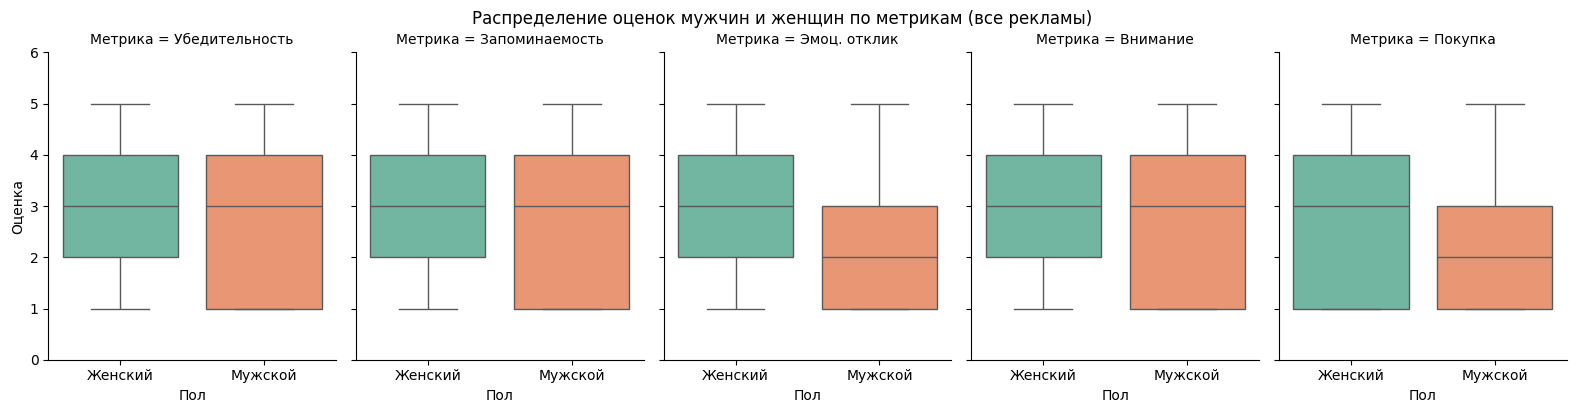

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Собираем список всех столбцов с баллами (1–5) по баннерам и метрикам.
# Опираемся на тот же список metric_keys, который использовался в U‑тесте.
metric_keys = [
    'убедительной',
    'запоминается',
    'эмоциональную',
    'привлекла',
    'склоняет'
]
short_names = ['Убедительность', 'Запоминаемость', 'Эмоц. отклик', 'Внимание', 'Покупка']

# Формируем длинную таблицу
rows = []
for i, col in enumerate(df.columns):
    col_lower = col.lower()
    for key, name in zip(metric_keys, short_names):
        if key in col_lower:
            # Извлекаем номер баннера из имени столбца (например, "Баннер 1")
            # У Вас столбцы называются иначе; подправьте по необходимости.
            # Допустим, имя столбца содержит "Баннер X" или "Banner X"
            banner = None
            # Попробуем найти номер баннера (1-10) в названии столбца
            import re
            match = re.search(r'(\d+)', col)
            if match:
                banner = int(match.group(1))
            else:
                # если номер не найден, пропускаем
                continue

            vals = df[col].dropna().astype(float)
            gender_series = df.loc[vals.index, 'Ваш пол']
            for v, g in zip(vals, gender_series):
                rows.append([banner, name, v, g])
            break

long_df = pd.DataFrame(rows, columns=['Баннер', 'Метрика', 'Оценка', 'Пол'])

# Строим ящики с усами: по горизонтали – пол, по вертикали – оценка, facet – метрика.
g = sns.catplot(
    data=long_df,
    x='Пол',
    y='Оценка',
    col='Метрика',
    kind='box',
    palette='Set2',
    height=4,
    aspect=0.8
)
g.fig.suptitle('Распределение оценок мужчин и женщин по метрикам (все рекламы)', y=1.02)
g.set(ylim=(0, 6))

# Сохраняем
g.savefig('boxplot_10_banners_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
result_df = pd.DataFrame(results)
print("\nРезультаты U-критерия Манна-Уитни (сравнение мужчин и женщин):")
print(result_df.to_string(index=False))

output_filename = "mannwhitney_results.xlsx"
result_df.to_excel(output_filename, index=False)
print(f"\nРезультаты сохранены в '{output_filename}'. Скачайте файл через панель слева.")


Результаты U-критерия Манна-Уитни (сравнение мужчин и женщин):
 Баннер              Метрика  U-статистика  p-value  Среднее (муж)  Среднее (жен)  Медиана (муж)  Медиана (жен) Значимость (p<0.05)
      1       Убедительность        1167.5  0.39198           2.27           2.48            2.0            3.0                 Нет
      1       Запоминаемость        1019.5  0.06494           2.54           3.03            3.0            3.0                 Нет
      1 Эмоциональный отклик        1212.0  0.58064           2.02           2.16            2.0            2.0                 Нет
      1             Внимание        1268.0  0.87445           2.41           2.48            2.0            2.0                 Нет
      1           Побуждение        1191.0  0.46911           1.80           1.87            1.0            2.0                 Нет
      2       Убедительность        1184.5  0.45563           2.95           3.13            3.0            3.0                 Нет
      2     

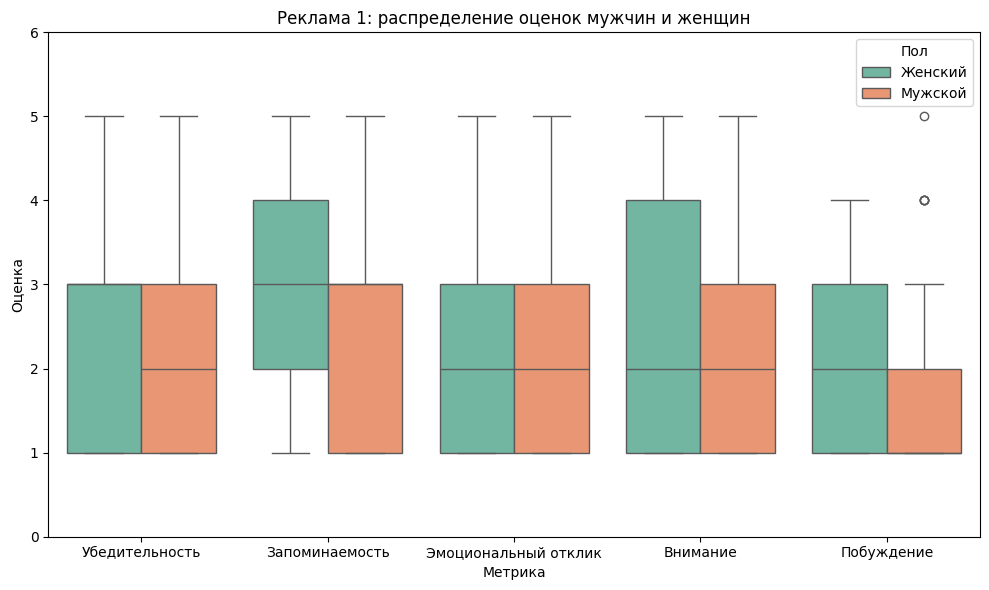

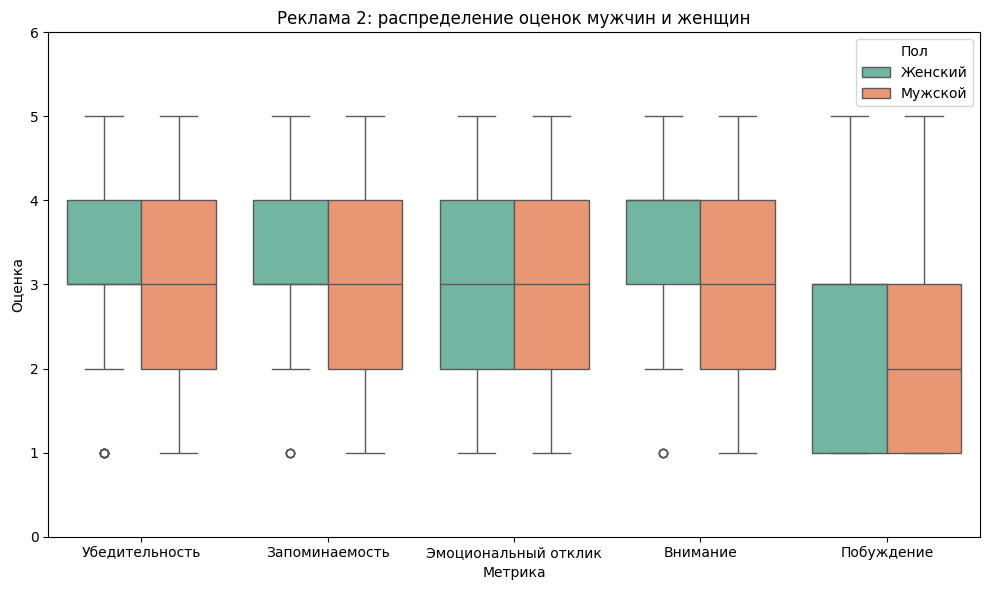

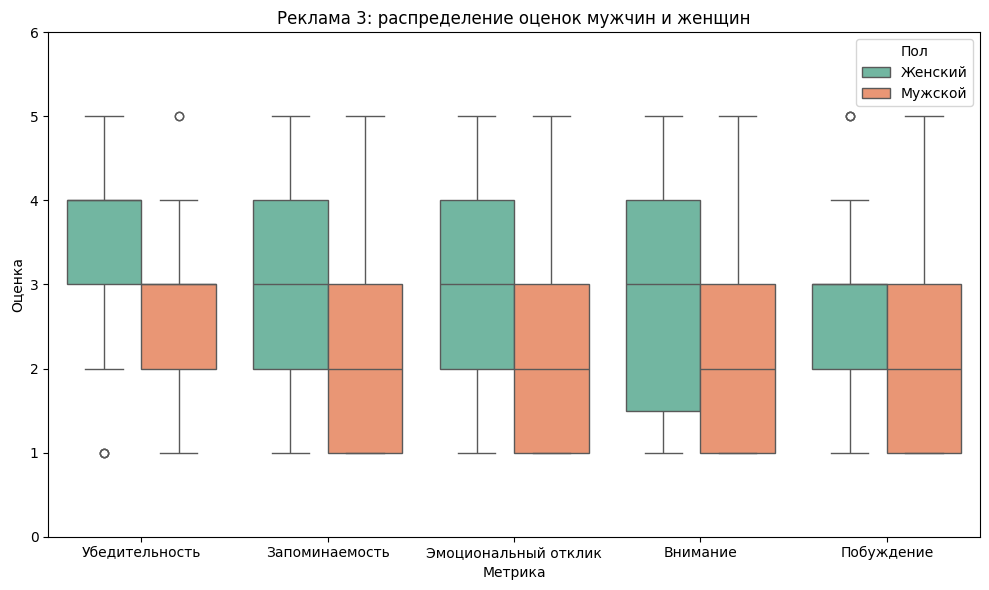

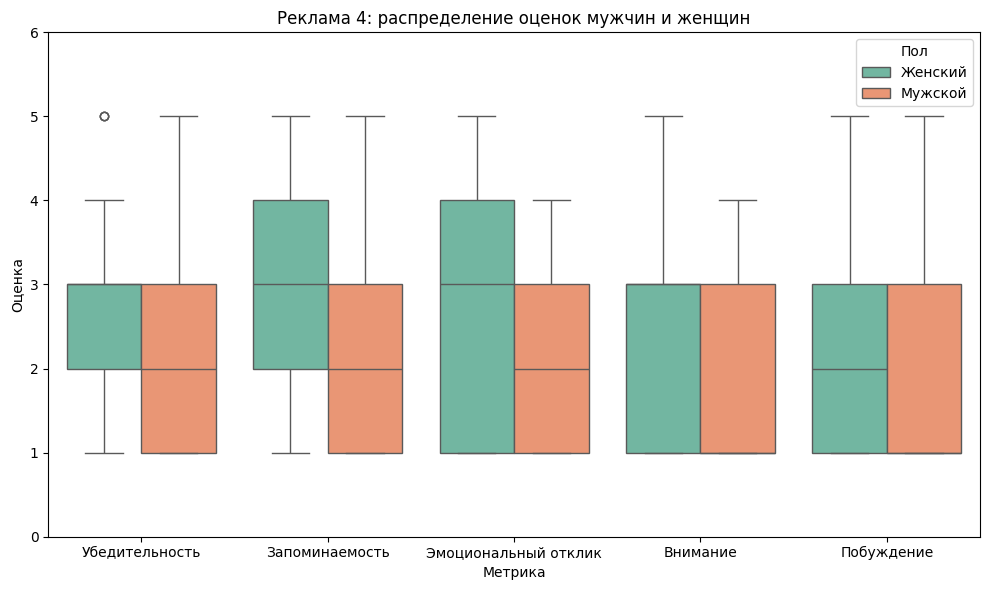

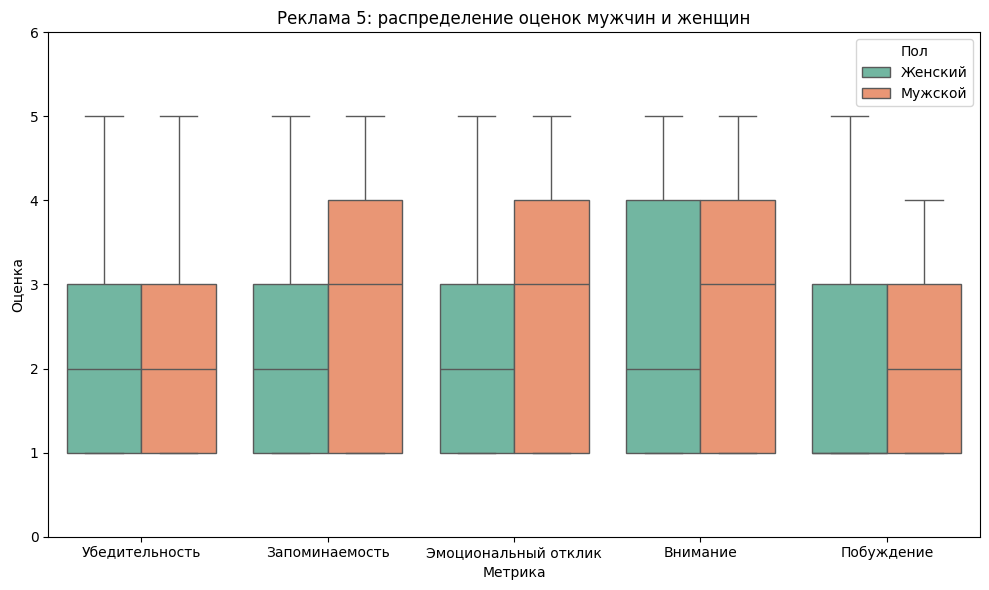

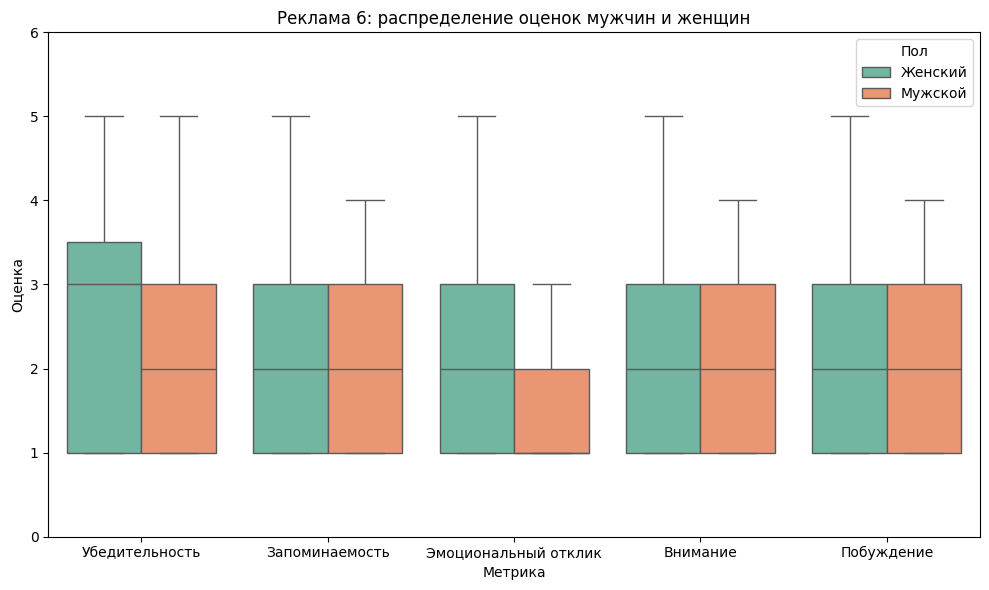

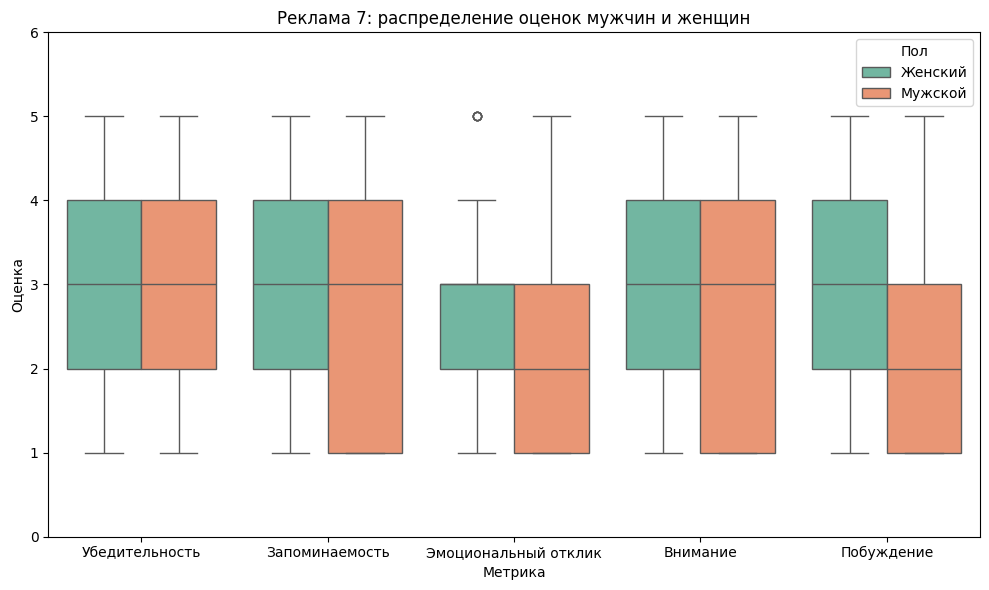

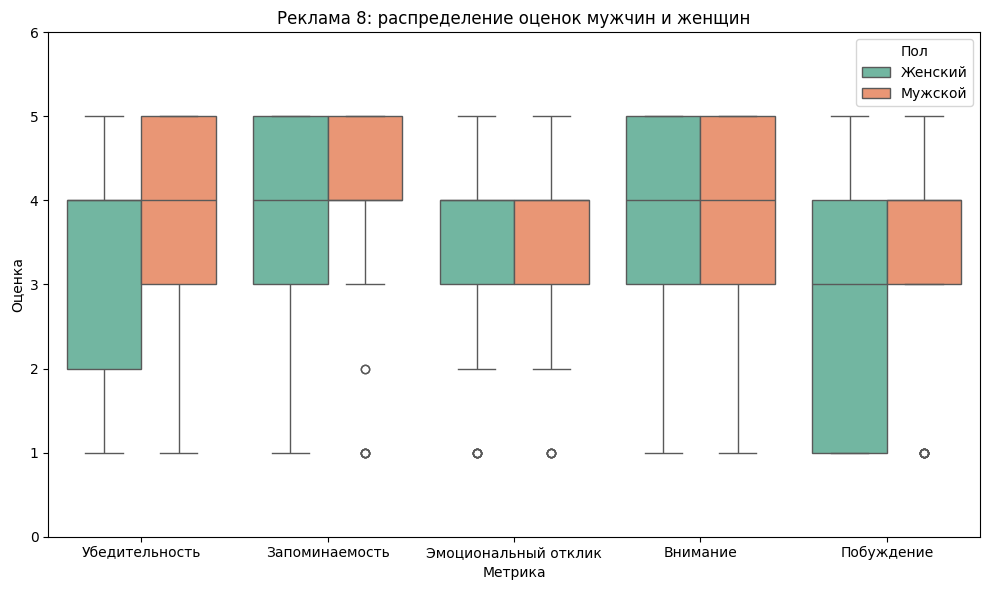

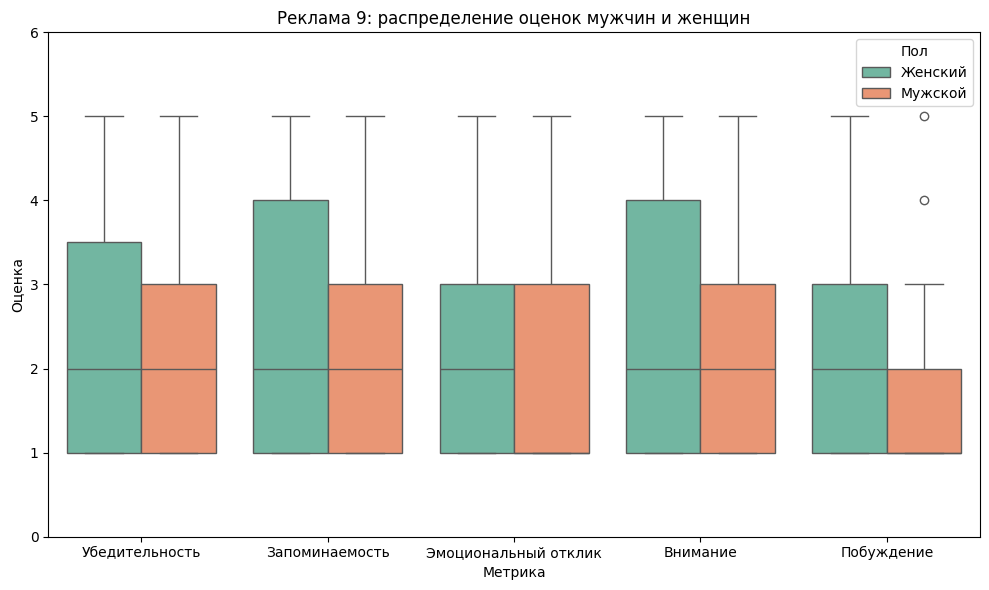

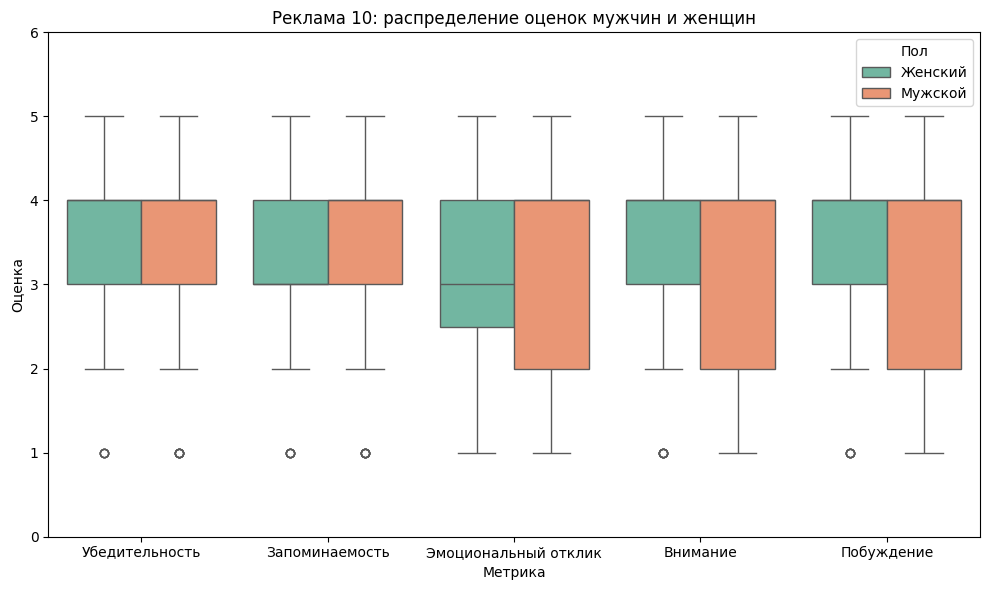

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Предполагается, что banner_columns, metrics_names и df уже существуют (как в вашем ноутбуке)

for banner_num in range(1, 11):
    cols = banner_columns.get(banner_num)
    if not cols:
        continue

    # Собираем длинную таблицу для текущего баннера
    rows = []
    for col, metric_name in zip(cols, metrics_names):
        # Берём только строки, где в нужном столбце есть числовые значения
        mask = df[col].notna()
        gender_series = df.loc[mask, 'Ваш пол'].astype(str).str.strip()
        values = df.loc[mask, col].astype(float)
        for g, v in zip(gender_series, values):
            rows.append([metric_name, v, g])

    banner_df = pd.DataFrame(rows, columns=['Метрика', 'Оценка', 'Пол'])

    # Построение графика
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=banner_df,
        x='Метрика',
        y='Оценка',
        hue='Пол',
        palette='Set2'
    )
    plt.title(f'Реклама {banner_num}: распределение оценок мужчин и женщин')
    plt.ylim(0, 6)                # шкала 1–5, с небольшим запасом
    plt.legend(title='Пол')
    plt.tight_layout()
    plt.savefig(f'boxplot_banner_{banner_num}.png', dpi=300, bbox_inches='tight')
    plt.show()